In [2]:
!pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 5.0 MB/s eta 0:00:00


In [4]:
#Bronze Layer
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()
np.random.seed(42)

# Generate 1000 sample transactions
data = {
    "transaction_id": [f"T{i:04d}" for i in range(1, 1001)],
    "user_id": [f"U{np.random.randint(1, 101):03d}" for _ in range(1000)],
    "product_name": np.random.choice(
        ["Laptop", "Headphones", "Mouse", "Keyboard", "Monitor", "USB Drive"], 
        size=1000
    ),
    "quantity": np.random.randint(1, 5, size=1000),
    "price": np.round(np.random.uniform(50, 1500, size=1000), 2),
    "transaction_date": [fake.date_between(start_date='-3M', end_date='today') for _ in range(1000)]
}

bronze_df = pd.DataFrame(data)

# Introduce some missing values for demonstration
for _ in range(20):
    bronze_df.loc[np.random.randint(0, 1000), 'price'] = np.nan
for _ in range(15):
    bronze_df.loc[np.random.randint(0, 1000), 'quantity'] = np.nan

# Save to CSV
bronze_df.to_csv("bronze_transactions.csv", index=False)
bronze_df.head()

,transaction_id,user_id,product_name,quantity,price,transaction_date
0,T0001,U052,Headphones,2.0,665.23,2026-02-13
1,T0002,U093,Laptop,2.0,169.80,2025-12-31
2,T0003,U015,Keyboard,2.0,796.25,2026-01-29
3,T0004,U072,Mouse,2.0,1353.41,2026-01-05
4,T0005,U061,Headphones,3.0,1184.60,2026-01-08


In [5]:
# Load the raw CSV
bronze_df = pd.read_csv("bronze_transactions.csv")
print("Bronze layer shape:", bronze_df.shape)
bronze_df.head()

Bronze layer shape: (1000, 6)


,transaction_id,user_id,product_name,quantity,price,transaction_date
0,T0001,U052,Headphones,2.0,665.23,2026-02-13
1,T0002,U093,Laptop,2.0,169.80,2025-12-31
2,T0003,U015,Keyboard,2.0,796.25,2026-01-29
3,T0004,U072,Mouse,2.0,1353.41,2026-01-05
4,T0005,U061,Headphones,3.0,1184.60,2026-01-08


In [6]:
#Silver Layer
# Remove duplicates
silver_df = bronze_df.drop_duplicates()

# Handle missing values
silver_df['quantity'] = silver_df['quantity'].fillna(1)  # assume default 1
silver_df['price'] = silver_df['price'].fillna(silver_df['price'].mean())

# Ensure correct data types
silver_df['quantity'] = silver_df['quantity'].astype(int)
silver_df['price'] = silver_df['price'].astype(float)
silver_df['transaction_date'] = pd.to_datetime(silver_df['transaction_date'])

# Add total_amount column
silver_df['total_amount'] = silver_df['quantity'] * silver_df['price']

# Save Silver layer CSV
silver_df.to_csv("silver_transactions.csv", index=False)
silver_df.head()

,transaction_id,user_id,product_name,quantity,price,transaction_date,total_amount
0,T0001,U052,Headphones,2,665.23,2026-02-13,1330.46
1,T0002,U093,Laptop,2,169.80,2025-12-31,339.60
2,T0003,U015,Keyboard,2,796.25,2026-01-29,1592.50
3,T0004,U072,Mouse,2,1353.41,2026-01-05,2706.82
4,T0005,U061,Headphones,3,1184.60,2026-01-08,3553.80


In [7]:
#Gold Layer
# Total revenue per product
gold_product = silver_df.groupby("product_name")["total_amount"].sum().reset_index()
gold_product = gold_product.sort_values(by="total_amount", ascending=False)

# Monthly revenue
silver_df['month'] = silver_df['transaction_date'].dt.to_period('M')
gold_monthly = silver_df.groupby('month')["total_amount"].sum().reset_index()

# Save Gold layer
gold_product.to_csv("gold_product_summary.csv", index=False)
gold_monthly.to_csv("gold_monthly_summary.csv", index=False)

gold_product.head()

,product_name,total_amount
4,Mouse,345706.509367
2,Laptop,341120.096245
3,Monitor,330965.166245
0,Headphones,307780.921041
5,USB Drive,300763.805520


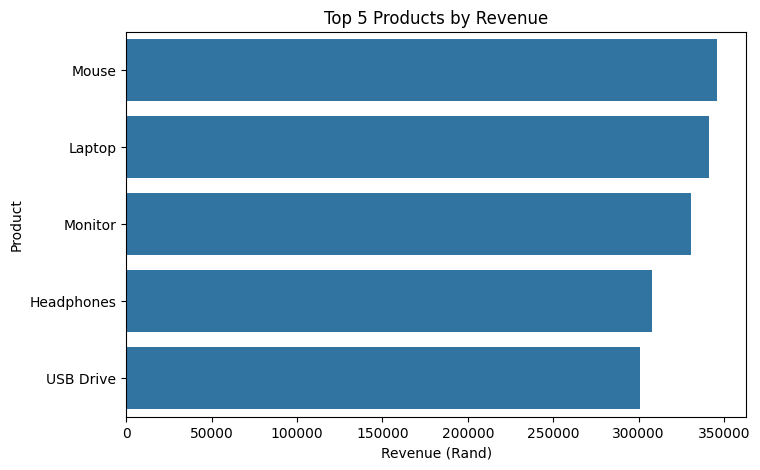

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 products by revenue
plt.figure(figsize=(8,5))
sns.barplot(data=gold_product.head(5), x="total_amount", y="product_name")
plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue (Rand)")
plt.ylabel("Product")
plt.show()

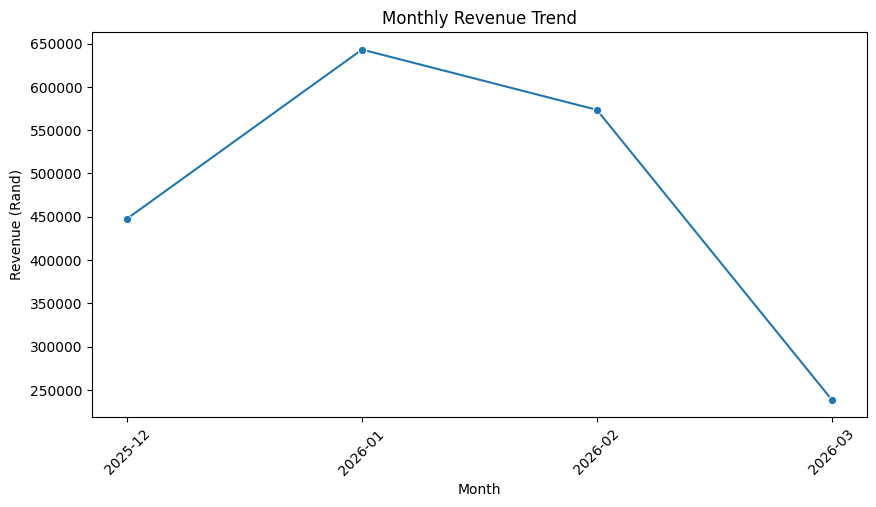

In [14]:
# Convert month to string for plotting
gold_monthly['month_str'] = gold_monthly['month'].astype(str)

# Plot monthly revenue trend
plt.figure(figsize=(10,5))
sns.lineplot(data=gold_monthly, x='month_str', y='total_amount', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Rand)")
plt.xticks(rotation=45)
plt.show()